In [5]:
import logging
from tmu.models.classification.vanilla_classifier import TMClassifier
import os
import config
import pickle
import numpy as np
from utils.optuna import save_optuna_best_results, load_optuna_best_results, run_tm_optuna_search
from utils.dataset import load_dataset
from utils.plots import plot_confusion_matrix_from_scores, plot_clause_length_distribution
from utils.booleanization import perform_canny_edge_detection_booleanization
from utils.training import train_tm_and_save_scores
from utils.clause_visualization import visualize_average_heatmap, visualize_per_channel_heatmaps, number_of_literals_in_clause, get_correct_sample_index, visualize_aggregated_heatmap, build_save_path, load_raw_maps_and_plot_heatmap

In [6]:
logging.getLogger("tmu").setLevel(logging.WARNING)
logging.getLogger("tmu.clause_bank.clause_bank_cuda").setLevel(logging.WARNING)
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
CURRENT_SPECIALIST = config.CANNY
CURRENT_DATASET = config.PNEUMONIAMNIST
CURRENT_RESOLUTION = 1 
specialist_name = ["Canny Edge"]

In [7]:
X_train_org, Y_train, X_val_org, Y_val, X_test_org, Y_test = load_dataset(config)

In [8]:
X_train, X_val, X_test, Y_train, Y_val, Y_test = perform_canny_edge_detection_booleanization(X_train_org, X_val_org, X_test_org, Y_train, Y_val, Y_test)

In [9]:
X_train = X_train.astype(np.uint32)
X_val   = X_val.astype(np.uint32)
X_test  = X_test.astype(np.uint32)
Y_test  = Y_test.astype(np.uint32)
Y_train  = Y_train.astype(np.uint32)
Y_val = Y_val.astype(np.uint32)

In [6]:
study = run_tm_optuna_search(TMClassifier, config, X_train, Y_train, X_val, Y_val, metric="fbeta", pos_label=1)

[I 2026-03-16 20:12:28,874] A new study created in memory with name: no-name-4ede4b55-2fd3-40ee-96f7-c738154f502f


[I 2026-03-16 21:09:12,987] Trial 0 finished with value: 0.8968963703314046 and parameters: {'s': 6.0, 'T': 10000, 'patch_size': 3, 'max_included_literals': 64}. Best is trial 0 with value: 0.8968963703314046.


[I 2026-03-16 22:01:46,680] Trial 1 finished with value: 0.8997901364113327 and parameters: {'s': 1.0, 'T': 10000, 'patch_size': 3, 'max_included_literals': 64}. Best is trial 1 with value: 0.8997901364113327.


[I 2026-03-16 22:55:51,788] Trial 2 finished with value: 0.9383100051840332 and parameters: {'s': 10.0, 'T': 2000, 'patch_size': 9, 'max_included_literals': 128}. Best is trial 2 with value: 0.9383100051840332.


[I 2026-03-16 23:54:30,290] Trial 3 finished with value: 0.9455958549222798 and parameters: {'s': 10.0, 'T': 2500, 'patch_size': 7, 'max_included_literals': 128}. Best is trial 3 with value: 0.9455958549222798.


...

[I 2026-03-18 19:21:38,008] Trial 46 finished with value: 0.9306569343065694 and parameters: {'s': 9.0, 'T': 2500, 'patch_size': 7, 'max_included_literals': 128}. Best is trial 19 with value: 0.9554634904194718.


[I 2026-03-18 20:31:15,774] Trial 47 finished with value: 0.9301719645648775 and parameters: {'s': 11.0, 'T': 7000, 'patch_size': 5, 'max_included_literals': 512}. Best is trial 19 with value: 0.9554634904194718.


[I 2026-03-18 21:38:36,933] Trial 48 finished with value: 0.9418785677218474 and parameters: {'s': 13.0, 'T': 1000, 'patch_size': 7, 'max_included_literals': 32}. Best is trial 19 with value: 0.9554634904194718.


[I 2026-03-18 22:46:19,883] Trial 49 finished with value: 0.9444732745199792 and parameters: {'s': 8.0, 'T': 3500, 'patch_size': 7, 'max_included_literals': 128}. Best is trial 19 with value: 0.9554634904194718.


Best fbeta: 0.9554634904194718
Best hyperparameters: {'s': 13.0, 'T': 2500, 'patch_size': 9, 'max_included_literals': 128}


In [7]:
best_params = study.best_params
print("Best F1 score macro accuracy:", study.best_value)
print("Best hyperparameters:", best_params)
save_optuna_best_results(study, "hyperparameters/canny_edge.json")

Best F1 score macro accuracy: 0.9554634904194718
Best hyperparameters: {'s': 13.0, 'T': 2500, 'patch_size': 9, 'max_included_literals': 128}
Best Optuna results saved to hyperparameters/canny_edge.json


In [10]:
best_value, best_params = load_optuna_best_results("hyperparameters/canny_edge.json")
s_best = best_params["s"]
T_best = best_params["T"]
patch_best = best_params["patch_size"]
weighted_best = 1
maxlit_best = best_params["max_included_literals"]

In [9]:
tm = train_tm_and_save_scores(
    TMClassifier=TMClassifier,
    config=config,
    X_train=X_train,
    Y_train=Y_train,
    X_test=X_test,
    Y_test=Y_test,
    T=T_best,
    s=s_best,
    patch_dim=patch_best,
    max_included_literals=maxlit_best,
    weighted_clauses=weighted_best,
    specialist_name="PneumoniaMNIST_Canny",
    save_dir=config.SAVE_DIR_SCORES,
)


Accuracy over 100 epochs:



#1 Accuracy: 83.65% (81.70s)


#2 Accuracy: 86.54% (74.15s)


#3 Accuracy: 86.38% (72.23s)


#4 Accuracy: 87.02% (71.17s)


...

#96 Accuracy: 85.90% (68.22s)


#97 Accuracy: 84.62% (68.07s)


#98 Accuracy: 84.46% (68.12s)


#99 Accuracy: 84.94% (68.19s)


#100 Accuracy: 84.78% (68.16s)


In [11]:
os.makedirs("saved_models", exist_ok=True)
model_path = os.path.join("saved_models", "PneumoniaMNIST_Canny_Specialist.pkl")

In [11]:
if not os.path.exists(model_path):
    with open(model_path, "wb") as f:
        pickle.dump(tm, f)
    print("Model saved.")
else:
    print("Model already exists. Skipping save.")

Model saved.


In [12]:
with open(model_path, "rb") as f:
    tm = pickle.load(f)

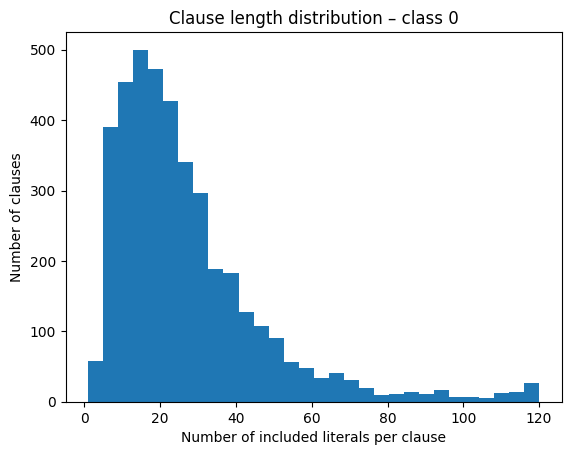

Class 0: median=22.0, mean=26.8, std=20.3


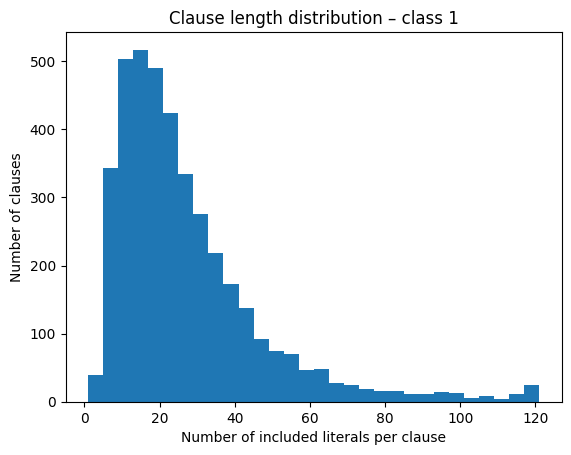

Class 1: median=21.0, mean=26.8, std=20.0


In [14]:
_ = plot_clause_length_distribution(tm)

Test Accuracy: 84.78%
2026-05-10 20:05:54,925 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-05-10 20:05:54,927 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-05-10 20:05:54,949 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7f19e7beb7d0>
Saved to saved_confusion_matrices/pneumonia_canny.svg


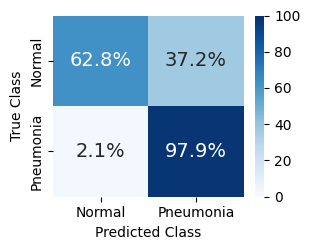

In [13]:
_, _ = plot_confusion_matrix_from_scores(config=config,  T= T_best, s= s_best, patch_size= patch_best, max_lit= maxlit_best, weighted= weighted_best, 
                                   Y_true=Y_test, specialist_name="PneumoniaMNIST_Canny", dataset_name=CURRENT_DATASET, save_specialist_name=CURRENT_SPECIALIST, figsize=(3.2, 2.6), annot_fontsize=14, cmap="Blues") 

# Class 0 Local Examples 

In [9]:
for i in range(3):
    image_index = get_correct_sample_index(tm, X_test, Y_test, target_class=0, random=True)
    print(f"Selected image index: {image_index}")
    print(f"True class: {Y_test[image_index]}")
    print(f"Predicted class: {tm.predict(X_test[image_index:image_index+1])[0]}")

Selected image index: 285
True class: 0
Predicted class: 0
Selected image index: 187
True class: 0
Predicted class: 0
Selected image index: 84
True class: 0
Predicted class: 0


0
2026-04-10 15:25:27,077 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-04-10 15:25:27,083 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
Visualizing sample 285  |  predicted class: 0
2026-04-10 15:25:27,125 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7e02c3ca7dd0>
Saved to saved_heatmaps/canny/pneumonia_canny_lh_c0_s285_aggr.svg


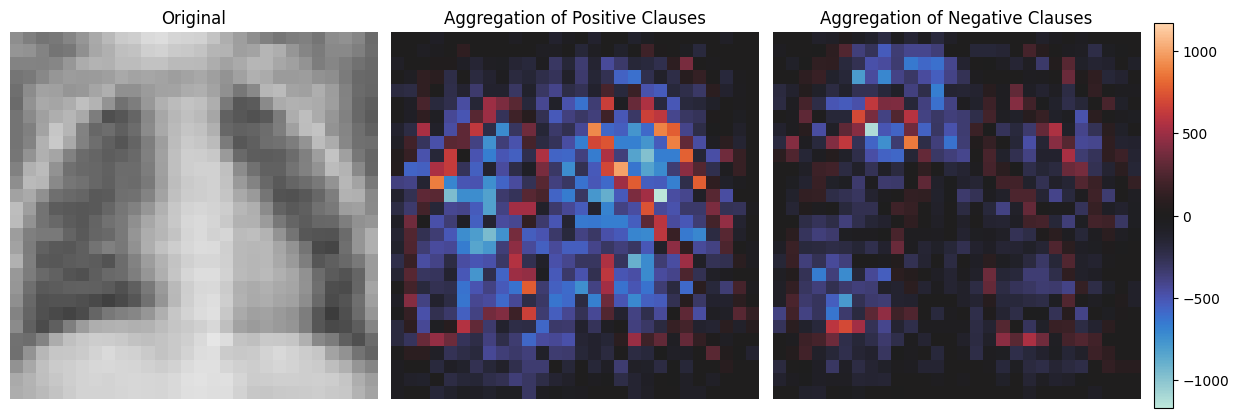

Visualizing sample 285  |  predicted class: 0
2026-04-10 15:25:30,316 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7e02bff2d4c0>
Saved to saved_heatmaps/canny/pneumonia_canny_lh_c0_s285_chan.svg


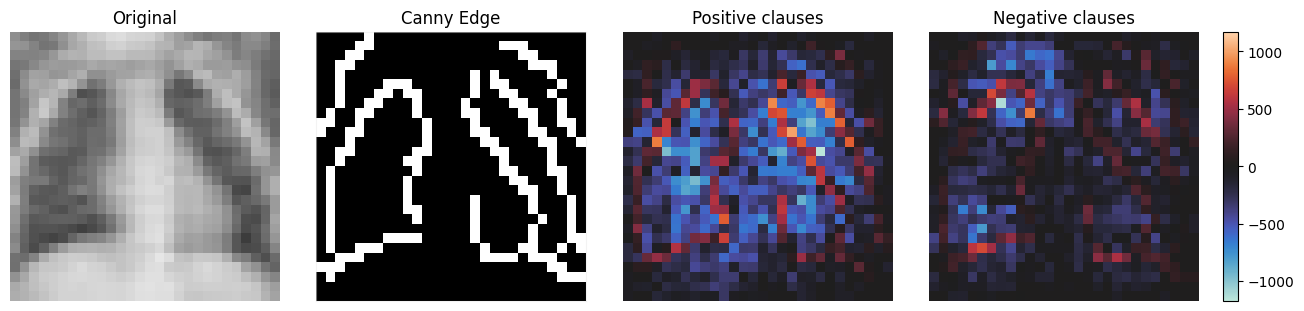

In [9]:
image_index =  285
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=specialist_name, save_path=save_path_per_channel)

0


Visualizing sample 187  |  predicted class: 0
2026-04-10 15:25:33,568 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7e02c3ca57f0>
Saved to saved_heatmaps/canny/pneumonia_canny_lh_c0_s187_aggr.svg


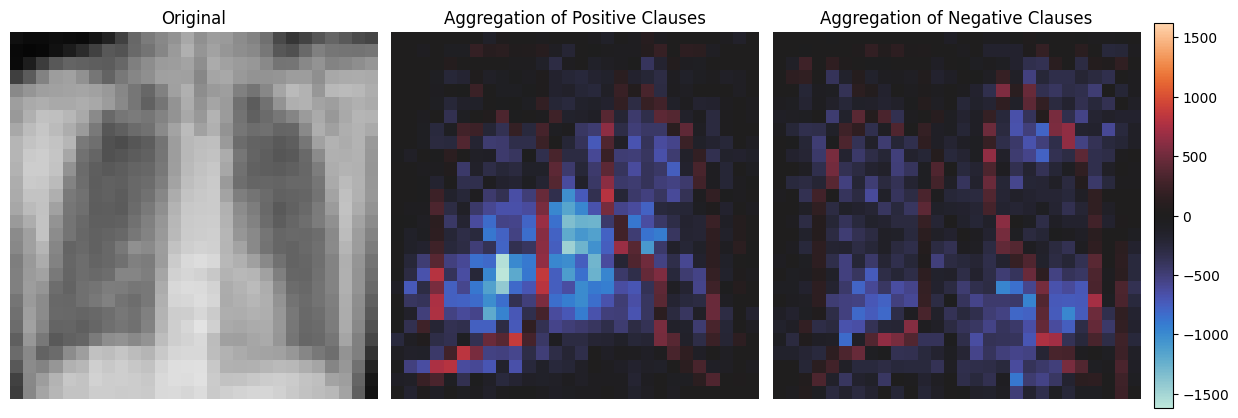

Visualizing sample 187  |  predicted class: 0
2026-04-10 15:25:36,830 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7e02bfe73d40>
Saved to saved_heatmaps/canny/pneumonia_canny_lh_c0_s187_chan.svg


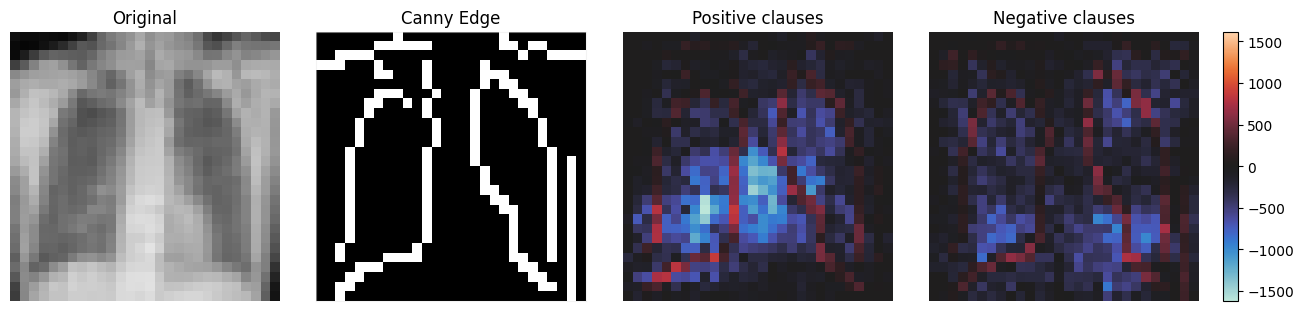

In [10]:
image_index =  187
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=specialist_name, save_path=save_path_per_channel)

0
Visualizing sample 84  |  predicted class: 0
2026-04-10 15:25:39,929 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7e02bc0c7680>
Saved to saved_heatmaps/canny/pneumonia_canny_lh_c0_s84_aggr.svg


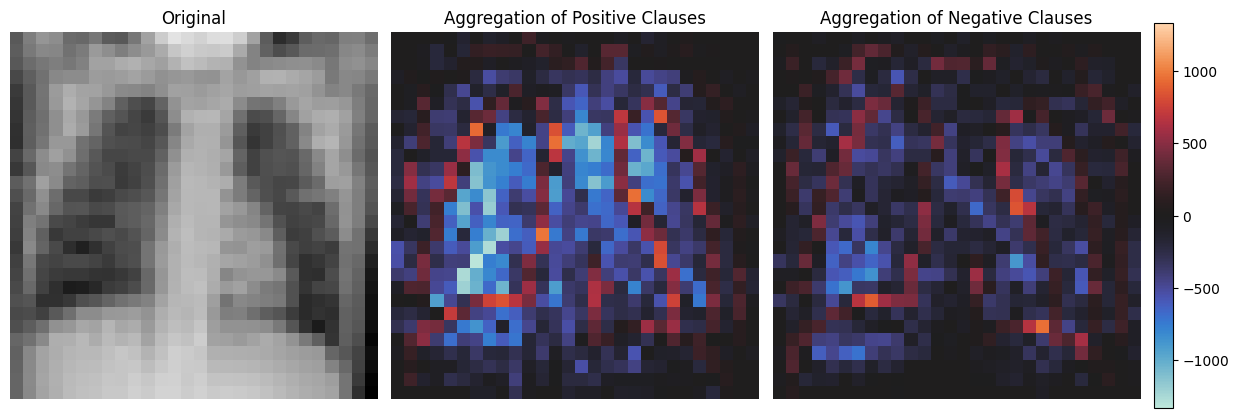

Visualizing sample 84  |  predicted class: 0
2026-04-10 15:25:43,034 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7e02a497d490>
Saved to saved_heatmaps/canny/pneumonia_canny_lh_c0_s84_chan.svg


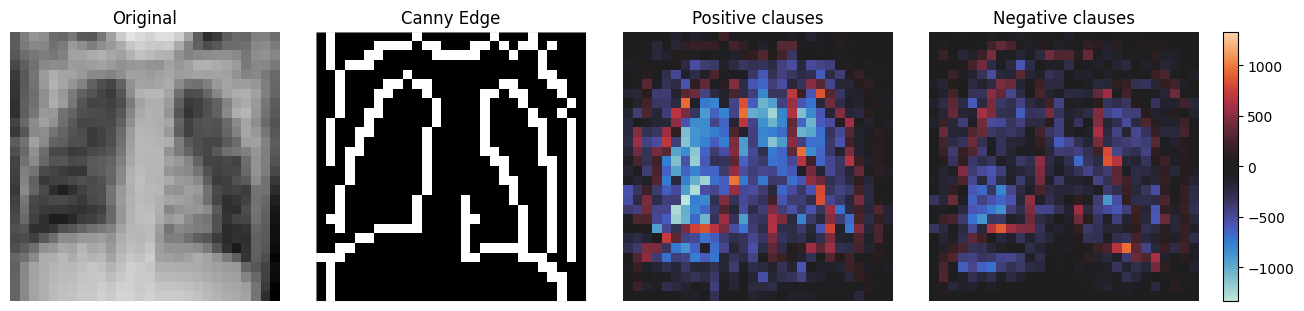

In [11]:
image_index =  84
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=specialist_name, save_path=save_path_per_channel)

# Class 1 Local Examples 

In [15]:
for i in range(3):
    image_index = get_correct_sample_index(tm, X_test, Y_test, target_class=1, random=True)
    print(f"Selected image index: {image_index}")
    print(f"True class: {Y_test[image_index]}")
    print(f"Predicted class: {tm.predict(X_test[image_index:image_index+1])[0]}")

Selected image index: 63
True class: 1
Predicted class: 1
Selected image index: 557
True class: 1
Predicted class: 1
Selected image index: 361
True class: 1
Predicted class: 1


1


Visualizing sample 132  |  predicted class: 1
2026-04-10 15:25:46,038 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7e02a4827290>
Saved to saved_heatmaps/canny/pneumonia_canny_lh_c1_s132_aggr.svg


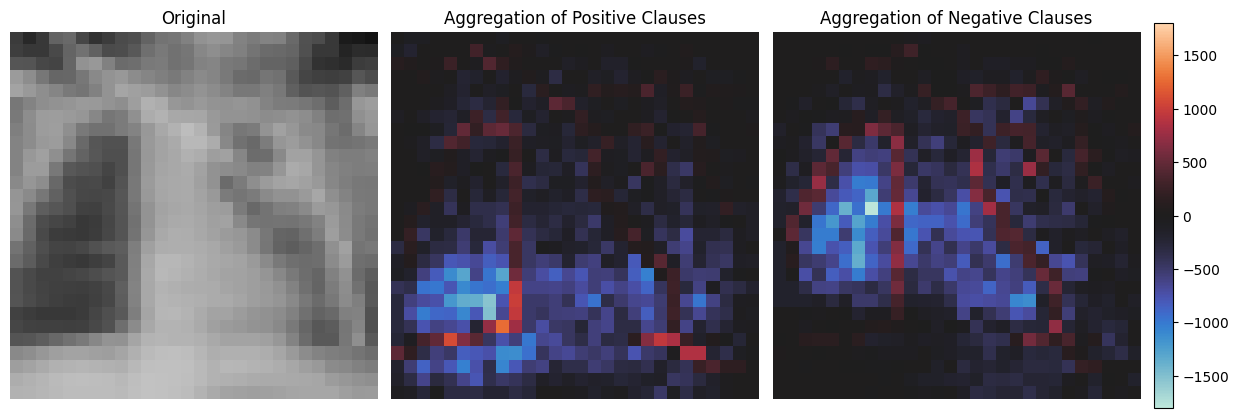

Visualizing sample 132  |  predicted class: 1
2026-04-10 15:25:49,006 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7e02bfce30b0>
Saved to saved_heatmaps/canny/pneumonia_canny_lh_c1_s132_chan.svg


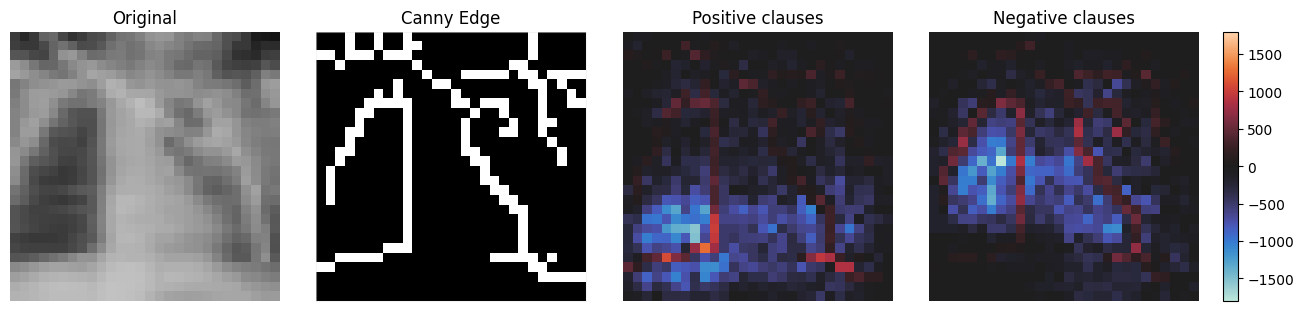

In [12]:
image_index =  132
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=specialist_name, save_path=save_path_per_channel)

1
Visualizing sample 528  |  predicted class: 1
2026-04-10 15:25:51,996 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7e02a452e360>
Saved to saved_heatmaps/canny/pneumonia_canny_lh_c1_s528_aggr.svg


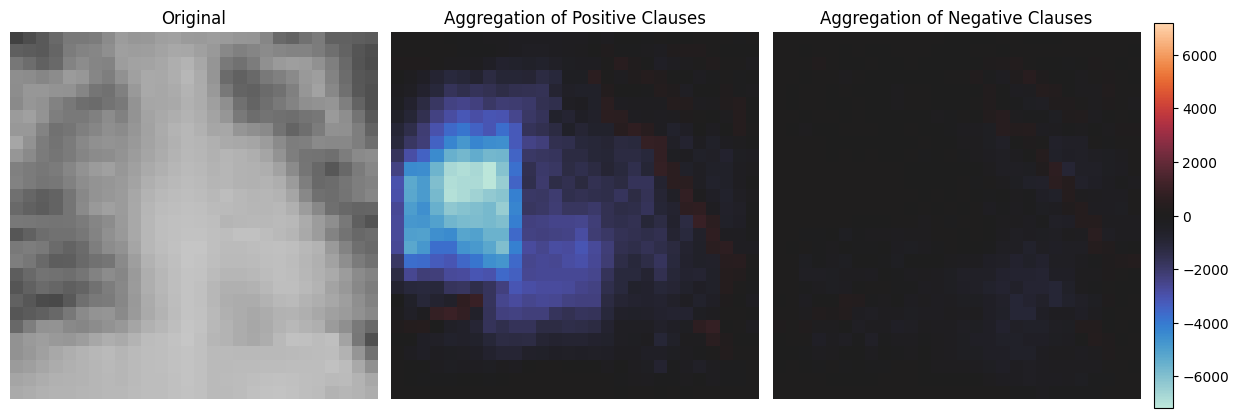

Visualizing sample 528  |  predicted class: 1
2026-04-10 15:25:55,506 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7e02a46ff3b0>
Saved to saved_heatmaps/canny/pneumonia_canny_lh_c1_s528_chan.svg


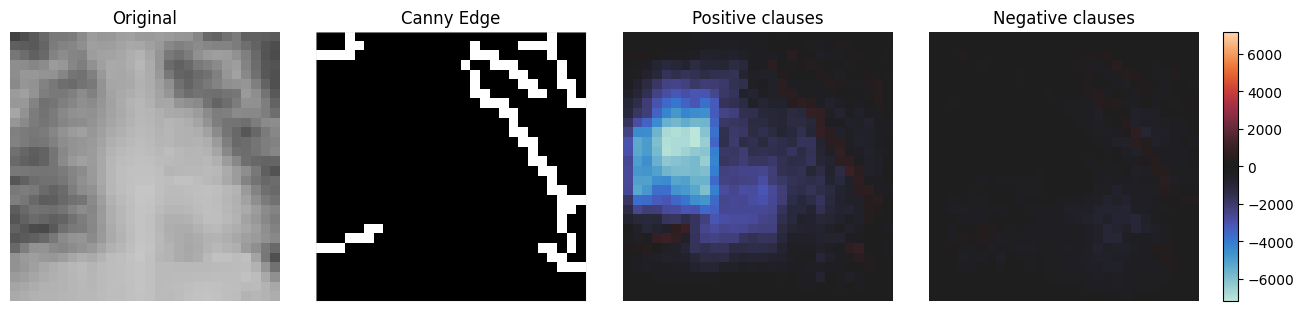

In [13]:
image_index =  528
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=specialist_name, save_path=save_path_per_channel)

1
Visualizing sample 63  |  predicted class: 1
2026-04-10 15:25:58,751 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7e02a45b8710>
Saved to saved_heatmaps/canny/pneumonia_canny_lh_c1_s63_aggr.svg


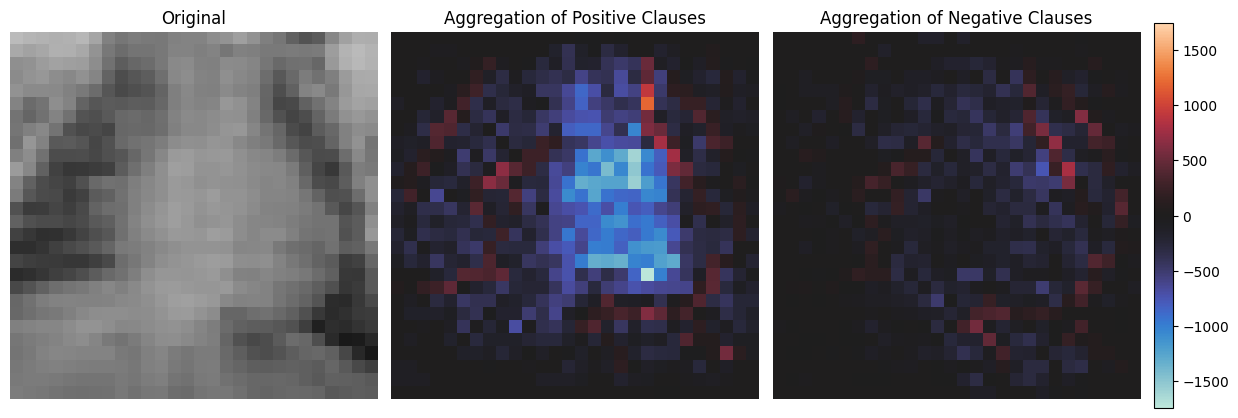

Visualizing sample 63  |  predicted class: 1
2026-04-10 15:26:02,056 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7e02a47f3890>
Saved to saved_heatmaps/canny/pneumonia_canny_lh_c1_s63_chan.svg


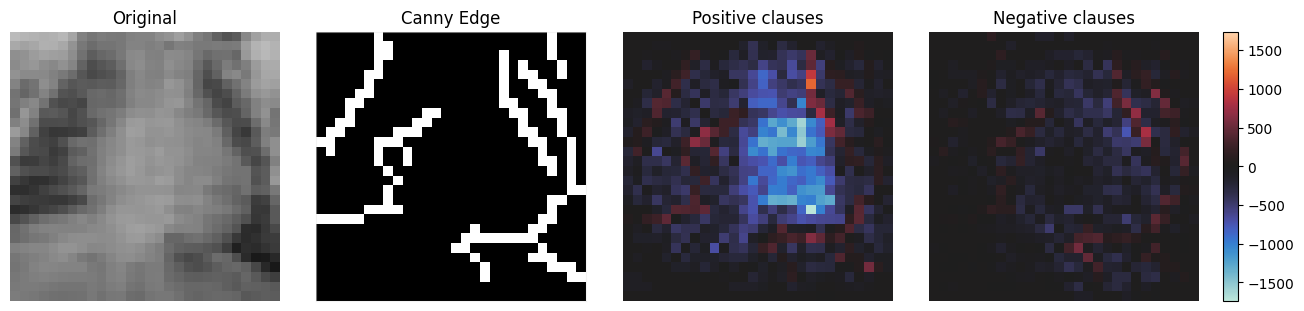

In [14]:
image_index =  63
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=specialist_name, save_path=save_path_per_channel)

# Global Heatmap 0

Averaging over 147 correctly predicted samples of class 0
  processed 100/147
2026-04-06 16:36:17,232 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x739b2d731760>


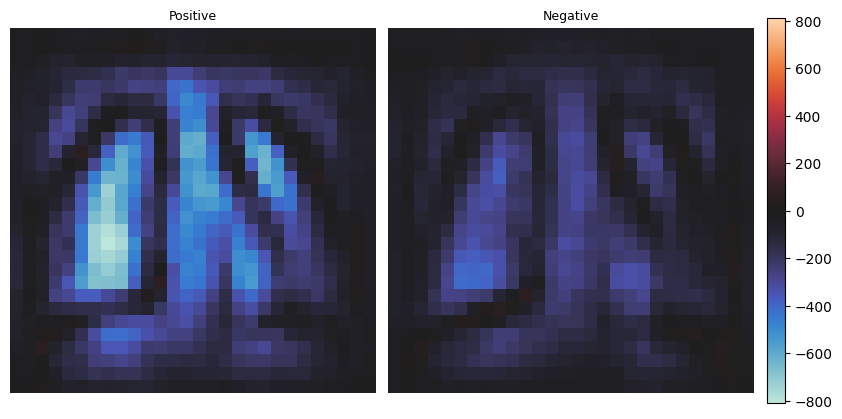

In [15]:
os.makedirs(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}", exist_ok=True)

target_class = 0

global_pos, global_neg, _ = visualize_average_heatmap(X_test, X_test_org, Y_test, tm, target_class=target_class,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), max_samples=None, show_diff=False, show_sample=False)


    
np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_pos.npy", global_pos)
np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_neg.npy", global_neg)

2026-04-10 19:14:18,265 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-04-10 19:14:18,268 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-04-10 19:14:18,292 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x710705139730>
Saved to saved_heatmaps/canny/pneumonia_canny_gh_c0.svg


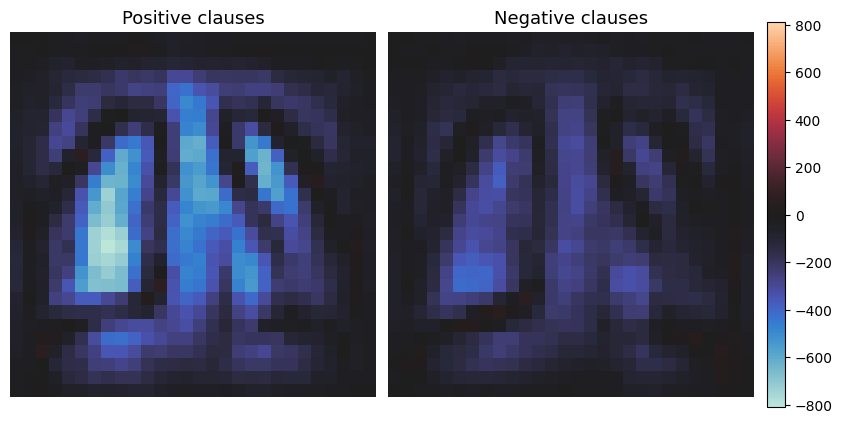

pos shape: (28, 28), min: -810.67, max: 69.74
neg shape: (28, 28), min: -414.22, max: 57.74
saved_heatmaps/canny/pneumonia_canny_gh_c0.svg


In [6]:
target_class = 0
save_path_global=build_save_path(base_dir=os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),dataset=CURRENT_DATASET, 
                                     specialist=CURRENT_SPECIALIST, heatmap_type=config.GLOBAL_HEATMAP, target_class=target_class)
load_raw_maps_and_plot_heatmap(config.SAVE_MAPS_DIR, CURRENT_SPECIALIST, target_class=target_class, save_path=save_path_global, title_pos=config.TITLE_GH_POS,
    title_neg=config.TITLE_GH_NEG)
print(save_path_global)

# Global Heatmap 1

Averaging over 382 correctly predicted samples of class 1
  processed 100/382
  processed 200/382
  processed 300/382
2026-04-06 16:53:49,545 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x739b2d77a450>


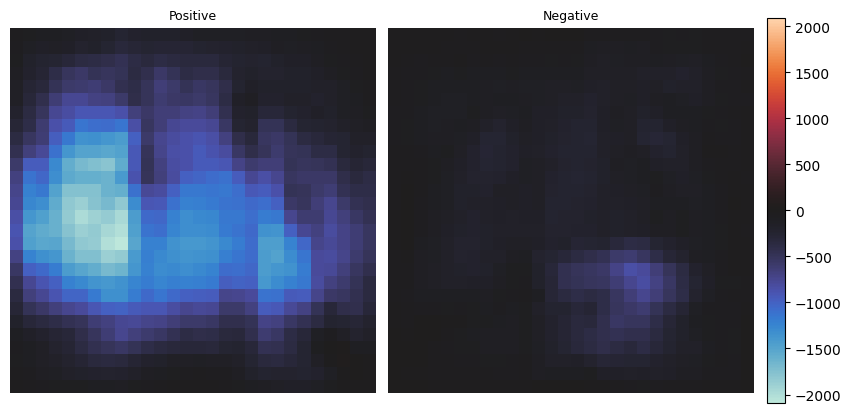

In [17]:
os.makedirs(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}", exist_ok=True)

target_class = 1

global_pos, global_neg, _ = visualize_average_heatmap(X_test, X_test_org, Y_test, tm, target_class=target_class,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), max_samples=None, show_diff=False, show_sample=False)


    
np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_pos.npy", global_pos)
np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_neg.npy", global_neg)

2026-04-10 19:14:21,414 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x71061a16cad0>


Saved to saved_heatmaps/canny/pneumonia_canny_gh_c1.svg


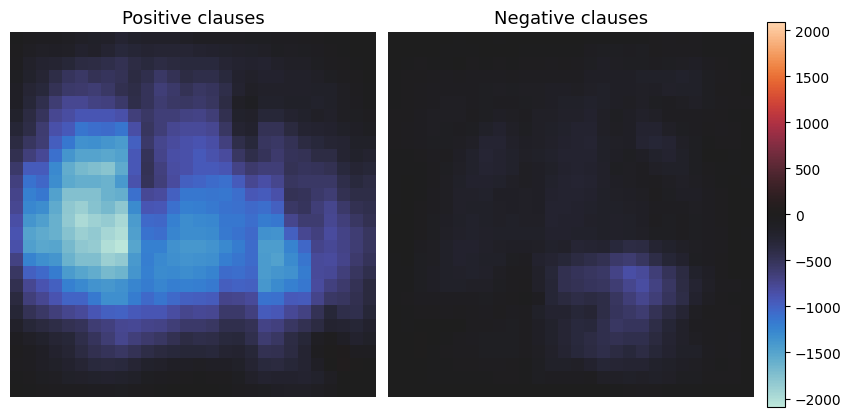

pos shape: (28, 28), min: -2092.27, max: 43.33
neg shape: (28, 28), min: -833.68, max: 8.27
saved_heatmaps/canny/pneumonia_canny_gh_c1.svg


In [7]:
target_class = 1
save_path_global=build_save_path(base_dir=os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),dataset=CURRENT_DATASET, 
                                     specialist=CURRENT_SPECIALIST, heatmap_type=config.GLOBAL_HEATMAP, target_class=target_class)
load_raw_maps_and_plot_heatmap(config.SAVE_MAPS_DIR, CURRENT_SPECIALIST, target_class=target_class, save_path=save_path_global, title_pos=config.TITLE_GH_POS,
    title_neg=config.TITLE_GH_NEG)
print(save_path_global)